# 01 — Delay Analysis and Product Decision Support

## Objective

This notebook analyzes rental delays on Getaround to support a product decision about the minimum time gap required between two consecutive rentals of the same vehicle.

The analysis aims to quantify the trade-off between:

* reducing friction caused by late vehicle returns;
* preserving rental availability for drivers and vehicle owners.

The final objective is to provide data-driven evidence for selecting:

1. a **minimum delay threshold** between consecutive rentals;
2. the **scope** of the policy: all rentals or Connect rentals only.

## Business Context

Getaround allows vehicle owners to rent their cars to drivers. When two rentals of the same vehicle are scheduled close together, a late return from the first rental may affect the next driver.

Introducing a minimum time gap between consecutive rentals could reduce these situations. However, increasing this gap may also prevent some rentals from being booked, reducing vehicle availability and potentially affecting revenue.

The analysis therefore focuses on the balance between **customer experience** and **rental availability**, without assuming that every late checkout creates a problem for the following rental.

## Methodology

The analysis will proceed in four stages:

1. **Data understanding and quality assessment**
   Inspect the workbook structure, variables, missing values, identifiers, and the unit of observation.

2. **Rental relationship investigation**
   Determine how consecutive rentals are represented and identify the variables linking a rental to the previous or next rental of the same vehicle.

3. **Delay impact analysis**
   Measure checkout delays and determine when a late return could actually interfere with a subsequent rental.

4. **Threshold simulation**
   Evaluate alternative minimum-delay thresholds and compare the share of rentals affected with the share of problematic situations potentially prevented.

The same analysis will be compared across the full rental population and the Connect scope where supported by the data.

## Notebook Structure

1. Imports and configuration
2. Data loading and workbook inspection
3. Dataset structure and data quality
4. Rental relationship investigation
5. Checkout delay analysis
6. Consecutive-rental impact analysis
7. Threshold simulation
8. Scope comparison
9. Business recommendation
10. Conclusions and limitations


In [3]:
# Imports and configuration
# ---------------------------------------------------------------------------

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Python version: 3.13.9
NumPy version: 2.3.5
Pandas version: 2.3.3


In [4]:
# Project paths
# ---------------------------------------------------------------------------

# Resolve project root whether the notebook runs from the project root
# or from the notebooks directory
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "get_around_delay_analysis.xlsx"
FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data file:    {DATA_PATH}")
print(f"Data exists:  {DATA_PATH.exists()}")

Project root: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\5_Getaround_Analysis_Deployment
Data file:    c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\5_Getaround_Analysis_Deployment\data\raw\get_around_delay_analysis.xlsx
Data exists:  True


In [5]:
# Inspect workbook structure
# ---------------------------------------------------------------------------

excel_file = pd.ExcelFile(DATA_PATH)

print("Available sheets:")
for sheet_name in excel_file.sheet_names:
    print(f"  - {sheet_name}")

Available sheets:
  - rentals_data
  - Documentation


In [6]:
# Inspect dataset documentation
# ---------------------------------------------------------------------------

documentation = pd.read_excel(
    DATA_PATH,
    sheet_name="Documentation",
    header=None
)

print(f"Documentation shape: {documentation.shape}")

display(documentation)

Documentation shape: (8, 2)


,0,1
0,field name,Comment
1,rental_id,Unique identifier of the rental
2,car_id,Unique identifier of the car
3,checkin_type,Flow used for both checkin and checkout. (ie. ...
4,state,canceled means that the rental did not happen ...
5,delay_at_checkout_in_minutes,Difference in minutes between the rental end t...
6,previous_ended_rental_id,id of the previous ended rental of the car (NU...
7,time_delta_with_previous_rental_in_minutes,Difference in minutes between this rental plan...


In [7]:
# Load rental data
# ---------------------------------------------------------------------------

df = pd.read_excel(
    DATA_PATH,
    sheet_name="rentals_data"
)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

display(df.head())

Dataset shape: 21,310 rows × 7 columns


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.00,NaN,NaN
2,508131,359049,connect,ended,70.00,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [8]:
# Inspect dataset schema
# ---------------------------------------------------------------------------

print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:>2}. {column}")

Columns:
 1. rental_id
 2. car_id
 3. checkin_type
 4. state
 5. delay_at_checkout_in_minutes
 6. previous_ended_rental_id
 7. time_delta_with_previous_rental_in_minutes


## 2. Dataset Structure and Data Quality

The dataset is now examined to establish its unit of observation, data types, completeness, identifier integrity, and the distribution of key categorical variables.

Particular attention is given to the fields describing checkout delays and consecutive rentals, as these variables will later determine whether a late return could interfere with the following rental.

No observations are removed or transformed at this stage.


In [9]:
# Dataset overview
# ---------------------------------------------------------------------------

print(f"Number of rows:    {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Unique rentals:    {df['rental_id'].nunique():,}")
print(f"Unique cars:       {df['car_id'].nunique():,}")
print(f"Duplicate rows:    {df.duplicated().sum():,}")
print(f"Duplicate rental IDs: {df['rental_id'].duplicated().sum():,}")


Number of rows:    21,310
Number of columns: 7
Unique rentals:    21,310
Unique cars:       8,143
Duplicate rows:    0
Duplicate rental IDs: 0


In [10]:
# Data types and missing values
# ---------------------------------------------------------------------------

quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique(dropna=True)
})

quality_summary

,dtype,missing_count,missing_pct,unique_values
rental_id,int64,0,0.00,21310
car_id,int64,0,0.00,8143
checkin_type,object,0,0.00,2
state,object,0,0.00,2
delay_at_checkout_in_minutes,float64,4964,23.29,1745
previous_ended_rental_id,float64,19469,91.36,1788
time_delta_with_previous_rental_in_minutes,float64,19469,91.36,25


In [11]:
# Inspect categorical variables
# ---------------------------------------------------------------------------

for column in ["checkin_type", "state"]:
    print(f"\n{column}")
    print("-" * len(column))
    
    counts = df[column].value_counts(dropna=False)
    percentages = df[column].value_counts(
        normalize=True,
        dropna=False
    ).mul(100).round(2)
    
    summary = pd.DataFrame({
        "count": counts,
        "percentage": percentages
    })
    
    display(summary)


checkin_type
------------


,count,percentage
checkin_type,,
mobile,17003,79.79
connect,4307,20.21



state
-----


,count,percentage
state,,
ended,18045,84.68
canceled,3265,15.32


In [12]:
# Inspect checkout delay
# ---------------------------------------------------------------------------

delay = df["delay_at_checkout_in_minutes"]

print(f"Available values: {delay.notna().sum():,}")
print(f"Missing values:   {delay.isna().sum():,}")
print(f"Minimum:          {delay.min():,.0f} minutes")
print(f"Maximum:          {delay.max():,.0f} minutes")
print(f"Median:           {delay.median():,.1f} minutes")
print(f"Mean:             {delay.mean():,.1f} minutes")

display(delay.describe())

Available values: 16,346
Missing values:   4,964
Minimum:          -22,433 minutes
Maximum:          71,084 minutes
Median:           9.0 minutes
Mean:             59.7 minutes


count    16,346.00
mean         59.70
std       1,002.56
min     -22,433.00
25%         -36.00
50%           9.00
75%          67.00
max      71,084.00
Name: delay_at_checkout_in_minutes, dtype: float64

In [14]:
# Investigate checkout-delay availability by rental state
# ---------------------------------------------------------------------------

delay_by_state = pd.crosstab(
    df["state"],
    df["delay_at_checkout_in_minutes"].isna()
)

delay_by_state.columns = ["delay_available", "delay_missing"]

delay_by_state["missing_pct"] = (
    delay_by_state["delay_missing"]
    / delay_by_state.sum(axis=1)
    * 100
).round(2)

delay_by_state

,delay_available,delay_missing,missing_pct
state,,,
canceled,1,3264,99.97
ended,16345,1700,9.42


In [15]:
# Inspect consecutive-rental relationships
# ---------------------------------------------------------------------------

has_previous_rental = df["previous_ended_rental_id"].notna()
has_time_delta = df["time_delta_with_previous_rental_in_minutes"].notna()

print(f"Rentals linked to a previous ended rental: {has_previous_rental.sum():,}")
print(f"Share of all rentals: {has_previous_rental.mean():.2%}")
print()
print(f"Rentals with a previous-rental time delta: {has_time_delta.sum():,}")
print(f"Share of all rentals: {has_time_delta.mean():.2%}")
print()
print(
    "Rows where previous rental ID and time delta availability disagree:",
    (has_previous_rental != has_time_delta).sum()
)

Rentals linked to a previous ended rental: 1,841
Share of all rentals: 8.64%

Rentals with a previous-rental time delta: 1,841
Share of all rentals: 8.64%

Rows where previous rental ID and time delta availability disagree: 0


### Initial Data Quality Findings

The dataset contains 21,310 unique rentals across 8,143 vehicles, with no duplicated rental records.

Checkout-delay information is available for most completed rentals but is structurally absent for almost all canceled rentals. Among ended rentals, 1,700 observations (9.42%) have no recorded checkout delay. These missing values will not be imputed because checkout delay is an observed operational outcome rather than a feature requiring estimation.

Consecutive-rental information is available for 1,841 rentals (8.64% of the dataset). For these observations, the previous rental identifier and the scheduled time gap with that rental are always available together, providing a consistent basis for investigating interactions between consecutive rentals.

The checkout-delay variable also contains a wide range of values. Distributional analysis will therefore consider robust statistics and visualizations rather than relying on the mean alone.


In [16]:
# Validate previous-rental references
# ---------------------------------------------------------------------------

linked_rentals = df.loc[
    df["previous_ended_rental_id"].notna()
].copy()

linked_rentals["previous_ended_rental_id"] = (
    linked_rentals["previous_ended_rental_id"].astype(int)
)

rental_ids = set(df["rental_id"])

linked_rentals["previous_rental_found"] = (
    linked_rentals["previous_ended_rental_id"].isin(rental_ids)
)

print(f"Linked rentals: {len(linked_rentals):,}")
print(
    "Previous rental IDs found in dataset: "
    f"{linked_rentals['previous_rental_found'].sum():,}"
)
print(
    "Previous rental IDs not found: "
    f"{(~linked_rentals['previous_rental_found']).sum():,}"
)

Linked rentals: 1,841
Previous rental IDs found in dataset: 1,841
Previous rental IDs not found: 0


In [17]:
# Join current rentals with their previous ended rental
# ---------------------------------------------------------------------------

previous_rentals = df[
    [
        "rental_id",
        "car_id",
        "checkin_type",
        "state",
        "delay_at_checkout_in_minutes"
    ]
].rename(
    columns={
        "rental_id": "previous_rental_id",
        "car_id": "previous_car_id",
        "checkin_type": "previous_checkin_type",
        "state": "previous_state",
        "delay_at_checkout_in_minutes": "previous_checkout_delay"
    }
)

linked_rentals = linked_rentals.merge(
    previous_rentals,
    left_on="previous_ended_rental_id",
    right_on="previous_rental_id",
    how="left"
)

display(linked_rentals.head())

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes,previous_rental_found,previous_rental_id,previous_car_id,previous_checkin_type,previous_state,previous_checkout_delay
0,511639,370585,connect,ended,-15.00,563782,570.00,True,563782,370585,connect,ended,136.00
1,519491,312389,mobile,ended,58.00,545639,420.00,True,545639,312389,mobile,ended,140.00
2,521156,392479,mobile,ended,NaN,537298,0.00,True,537298,392479,mobile,ended,NaN
3,525044,349751,mobile,ended,NaN,510607,60.00,True,510607,349751,mobile,ended,-113.00
4,528808,181625,connect,ended,-76.00,557404,330.00,True,557404,181625,connect,ended,-352.00


In [18]:
# Validate consecutive-rental consistency
# ---------------------------------------------------------------------------

print(
    "Linked rentals belonging to the same car: "
    f"{(linked_rentals['car_id'] == linked_rentals['previous_car_id']).sum():,}"
    f" / {len(linked_rentals):,}"
)

print("\nPrevious rental states:")
print(linked_rentals["previous_state"].value_counts(dropna=False))

print("\nMissing previous checkout delays:")
print(linked_rentals["previous_checkout_delay"].isna().value_counts())

Linked rentals belonging to the same car: 1,841 / 1,841

Previous rental states:
previous_state
ended    1841
Name: count, dtype: int64

Missing previous checkout delays:
previous_checkout_delay
False    1729
True      112
Name: count, dtype: int64


### Consecutive Rental Relationship Validation

The consecutive-rental structure is internally consistent. All 1,841 rentals referencing a previous ended rental point to a rental present in the dataset, and every linked pair belongs to the same vehicle. All referenced previous rentals also have the expected `ended` state.

Checkout-delay information for the previous rental is available for 1,729 of the 1,841 linked pairs. The remaining 112 pairs cannot be directly evaluated for delay-related interference because the previous rental's checkout delay is unknown. These missing delays will not be imputed.

This validated relationship provides the basis for comparing the previous rental's checkout delay with the scheduled time gap before the following rental.


### Business logic 

For a previous rental, the documentation tells us delay_at_checkout_in_minutes measures the difference between actual checkout and planned end. Therefore:

delay > 0  → returned late
delay = 0  → returned on time
delay < 0  → returned early

For the current rental, time_delta_with_previous_rental_in_minutes gives us the scheduled buffer after that previous rental.

## 3. Analytical Definitions

A late checkout does not necessarily create a problem for the following driver. The impact depends on both the previous rental's checkout delay and the scheduled time gap between the two rentals.

The analysis therefore distinguishes the following concepts:

* **Late checkout:** the previous rental ended after its scheduled checkout time (`checkout delay > 0`).
* **Scheduled buffer:** the planned number of minutes between the end of the previous rental and the start of the following rental.
* **Problematic consecutive rental:** the previous rental's checkout delay exceeds the scheduled buffer before the following rental.
* **Interference duration:** the number of minutes by which the previous rental's delay exceeds the available scheduled buffer.

For example, a rental returned 30 minutes late followed by another rental 60 minutes later is late but does not directly interfere with the following rental. In contrast, a 90-minute late return with a 60-minute scheduled buffer exceeds the available gap by 30 minutes and is classified as a problematic consecutive-rental situation.

Only linked rental pairs with an observed checkout delay for the previous rental can be evaluated for this outcome.


In [19]:
# Build the analyzable consecutive-rental sample
# ---------------------------------------------------------------------------

consecutive = linked_rentals.loc[
    linked_rentals["previous_checkout_delay"].notna()
].copy()

consecutive["previous_rental_late"] = (
    consecutive["previous_checkout_delay"] > 0
)

consecutive["problematic_case"] = (
    consecutive["previous_checkout_delay"]
    > consecutive["time_delta_with_previous_rental_in_minutes"]
)

consecutive["interference_minutes"] = (
    consecutive["previous_checkout_delay"]
    - consecutive["time_delta_with_previous_rental_in_minutes"]
).clip(lower=0)

print(f"Linked rental pairs:          {len(linked_rentals):,}")
print(f"Analyzable linked pairs:      {len(consecutive):,}")
print(
    f"Excluded for missing delay:   "
    f"{linked_rentals['previous_checkout_delay'].isna().sum():,}"
)

Linked rental pairs:          1,841
Analyzable linked pairs:      1,729
Excluded for missing delay:   112


In [20]:
# Quantify late returns and actual next-rental interference
# ---------------------------------------------------------------------------

n_consecutive = len(consecutive)
n_late = consecutive["previous_rental_late"].sum()
n_problematic = consecutive["problematic_case"].sum()

print(f"Analyzable consecutive pairs: {n_consecutive:,}")
print()
print(
    f"Previous rentals returned late: "
    f"{n_late:,} ({n_late / n_consecutive:.2%})"
)
print(
    f"Problematic consecutive cases:  "
    f"{n_problematic:,} ({n_problematic / n_consecutive:.2%})"
)

if n_late > 0:
    print(
        f"Share of late returns causing interference: "
        f"{n_problematic / n_late:.2%}"
    )

Analyzable consecutive pairs: 1,729

Previous rentals returned late: 873 (50.49%)
Problematic consecutive cases:  218 (12.61%)
Share of late returns causing interference: 24.97%


In [21]:
# Inspect problematic cases
# ---------------------------------------------------------------------------

problematic_cases = consecutive.loc[
    consecutive["problematic_case"],
    [
        "previous_rental_id",
        "rental_id",
        "car_id",
        "checkin_type",
        "previous_checkin_type",
        "previous_checkout_delay",
        "time_delta_with_previous_rental_in_minutes",
        "interference_minutes"
    ]
].copy()

display(problematic_cases.head(10))

display(
    problematic_cases[
        [
            "previous_checkout_delay",
            "time_delta_with_previous_rental_in_minutes",
            "interference_minutes"
        ]
    ].describe()
)

,previous_rental_id,rental_id,car_id,checkin_type,previous_checkin_type,previous_checkout_delay,time_delta_with_previous_rental_in_minutes,interference_minutes
11,539751,540479,374684,mobile,mobile,3.00,0.00,3.00
12,540607,541862,382364,mobile,mobile,1.00,0.00,1.00
37,540868,559781,408776,mobile,mobile,26.00,0.00,26.00
64,572909,574568,301512,mobile,mobile,13.00,0.00,13.00
68,533413,535519,353425,connect,connect,4.00,0.00,4.00
69,541519,537441,408821,mobile,mobile,95.00,90.00,5.00
88,536978,544473,378931,mobile,mobile,271.00,60.00,211.00
93,514474,543108,376574,mobile,mobile,81.00,0.00,81.00
122,548646,539151,282893,mobile,mobile,201.00,30.00,171.00
128,548169,547655,375834,mobile,mobile,5.00,0.00,5.00


,previous_checkout_delay,time_delta_with_previous_rental_in_minutes,interference_minutes
count,218.00,218.00,218.00
mean,238.94,61.38,177.57
std,961.03,124.70,925.10
min,1.00,0.00,1.00
25%,18.75,0.00,11.00
50%,65.00,0.00,26.50
75%,163.75,60.00,80.25
max,"12,968.00",720.00,"12,548.00"


### Late Returns vs. Next-Rental Interference

Among the 1,729 consecutive-rental pairs with an observed checkout delay for the previous rental, 873 (50.49%) involved a late return.

However, only 218 pairs (12.61%) involved a delay that exceeded the scheduled buffer before the following rental. In other words, approximately one quarter (24.97%) of late returns in this analyzable consecutive-rental sample were late enough to directly interfere with the next scheduled rental.

This distinction is important for the product decision: a policy designed solely around the frequency of late returns would overstate the number of situations in which the following driver is directly exposed to the delay.


In [22]:
# Checkout-delay distribution among ended rentals
# ---------------------------------------------------------------------------

ended_with_delay = df.loc[
    (df["state"] == "ended")
    & df["delay_at_checkout_in_minutes"].notna()
].copy()

ended_with_delay["is_late"] = (
    ended_with_delay["delay_at_checkout_in_minutes"] > 0
)

print(f"Ended rentals with observed delay: {len(ended_with_delay):,}")
print(
    f"Returned late: "
    f"{ended_with_delay['is_late'].sum():,} "
    f"({ended_with_delay['is_late'].mean():.2%})"
)
print(
    f"Returned on time or early: "
    f"{(~ended_with_delay['is_late']).sum():,} "
    f"{(~ended_with_delay['is_late']).mean():.2%}"
)

Ended rentals with observed delay: 16,345
Returned late: 9,404 (57.53%)
Returned on time or early: 6,941 42.47%


In [23]:
# Robust checkout-delay statistics
# ---------------------------------------------------------------------------

delay_percentiles = ended_with_delay[
    "delay_at_checkout_in_minutes"
].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

print("Checkout-delay percentiles (minutes):")
display(delay_percentiles.to_frame(name="delay_minutes"))

Checkout-delay percentiles (minutes):


,delay_minutes
0.01,-853.00
0.05,-230.00
0.25,-36.00
0.50,9.00
0.75,67.00
0.95,397.80
0.99,"1,490.56"


In [24]:
# Distribution of late checkout delays
# ---------------------------------------------------------------------------

late_delays = ended_with_delay.loc[
    ended_with_delay["is_late"],
    "delay_at_checkout_in_minutes"
]

late_delay_summary = late_delays.quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="late_delay_minutes")

print(f"Late checkouts: {len(late_delays):,}")
print(f"Median late delay: {late_delays.median():,.1f} minutes")
print(f"Mean late delay:   {late_delays.mean():,.1f} minutes")
print()

display(late_delay_summary)

Late checkouts: 9,404
Median late delay: 53.0 minutes
Mean late delay:   201.8 minutes



,late_delay_minutes
0.25,19.00
0.50,53.00
0.75,131.00
0.90,338.00
0.95,745.00
0.99,"2,408.76"


In [25]:
# Inspect scheduled gaps between consecutive rentals
# ---------------------------------------------------------------------------

gap_summary = (
    linked_rentals["time_delta_with_previous_rental_in_minutes"]
    .value_counts()
    .sort_index()
    .rename_axis("gap_minutes")
    .to_frame("count")
)

gap_summary["percentage"] = (
    gap_summary["count"] / gap_summary["count"].sum() * 100
).round(2)

display(gap_summary)

,count,percentage
gap_minutes,,
0.00,279,15.15
30.00,122,6.63
60.00,183,9.94
90.00,82,4.45
120.00,137,7.44
150.00,67,3.64
180.00,83,4.51
210.00,48,2.61
240.00,67,3.64


### Checkout Delay Characteristics

Among the 16,345 ended rentals with an observed checkout delay, 9,404 (57.53%) were returned after their scheduled checkout time.

Late-return durations are strongly right-skewed. The median late checkout is 53 minutes, while the mean reaches 201.8 minutes. Three quarters of late returns are within 131 minutes, but a small number of substantially longer delays increase the mean considerably. Robust statistics such as the median and percentiles are therefore more representative of typical checkout behavior than the mean alone.

Scheduled gaps between consecutive rentals occur in 30-minute increments ranging from 0 to 720 minutes. This discrete structure provides a natural basis for evaluating alternative minimum-delay thresholds.


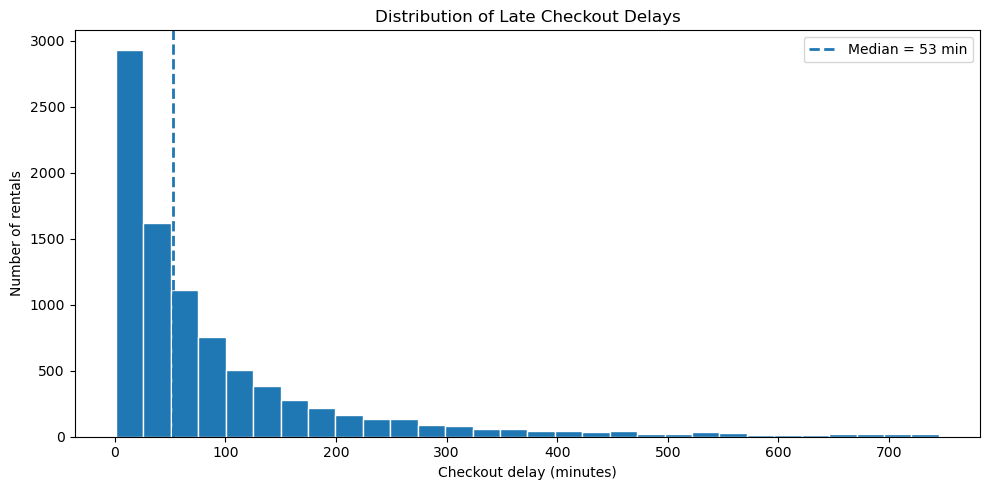

In [26]:
# Visualize the distribution of late checkout delays
# ---------------------------------------------------------------------------

late_delay_p95 = late_delays.quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    late_delays[late_delays <= late_delay_p95],
    bins=30,
    edgecolor="white"
)

ax.axvline(
    late_delays.median(),
    linestyle="--",
    linewidth=2,
    label=f"Median = {late_delays.median():.0f} min"
)

ax.set_title("Distribution of Late Checkout Delays")
ax.set_xlabel("Checkout delay (minutes)")
ax.set_ylabel("Number of rentals")
ax.legend()

fig.tight_layout()

plt.show()

In [27]:
# Save figure for project documentation
# ---------------------------------------------------------------------------

figure_path = FIGURES_PATH / "late_checkout_distribution.png"

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

print(f"Figure saved to: {figure_path}")

Figure saved to: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\5_Getaround_Analysis_Deployment\outputs\figures\late_checkout_distribution.png


In [28]:
# Compare checkout behavior by check-in type
# ---------------------------------------------------------------------------

checkin_summary = (
    ended_with_delay
    .groupby("checkin_type")
    .agg(
        rentals=("rental_id", "count"),
        late_rentals=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_delay=("delay_at_checkout_in_minutes", "median")
    )
)

checkin_summary["late_rate"] = (
    checkin_summary["late_rate"] * 100
).round(2)

checkin_summary["median_late_delay"] = (
    ended_with_delay.loc[ended_with_delay["is_late"]]
    .groupby("checkin_type")["delay_at_checkout_in_minutes"]
    .median()
)

checkin_summary

,rentals,late_rentals,late_rate,median_delay,median_late_delay
checkin_type,,,,,
connect,3402,1459,42.89,-9.00,41.00
mobile,12943,7945,61.38,14.00,56.00


In [29]:
# Compare consecutive-rental interference by check-in type
# ---------------------------------------------------------------------------

interference_by_type = (
    consecutive
    .groupby("checkin_type")
    .agg(
        consecutive_pairs=("rental_id", "count"),
        late_previous_rentals=("previous_rental_late", "sum"),
        problematic_cases=("problematic_case", "sum")
    )
)

interference_by_type["late_previous_rate"] = (
    interference_by_type["late_previous_rentals"]
    / interference_by_type["consecutive_pairs"]
    * 100
).round(2)

interference_by_type["problematic_rate"] = (
    interference_by_type["problematic_cases"]
    / interference_by_type["consecutive_pairs"]
    * 100
).round(2)

interference_by_type

,consecutive_pairs,late_previous_rentals,problematic_cases,late_previous_rate,problematic_rate
checkin_type,,,,,
connect,791,304,69,38.43,8.72
mobile,938,569,149,60.66,15.88


In [30]:
# Check whether consecutive rentals use the same check-in type
# ---------------------------------------------------------------------------

checkin_transition = pd.crosstab(
    linked_rentals["previous_checkin_type"],
    linked_rentals["checkin_type"],
    margins=True
)

checkin_transition

checkin_type,connect,mobile,All
previous_checkin_type,,,
connect,801,5,806
mobile,12,1023,1035
All,813,1028,1841


### Check-in Type and Policy Scope

The dataset distinguishes two check-in and checkout flows. `mobile` corresponds to rentals where the rental agreement is managed through the owner's smartphone, while `connect` corresponds to cars equipped with Getaround Connect technology and accessed by the driver through their smartphone.

This variable therefore provides the basis for evaluating the two policy scopes requested by the Product Manager:

* **All cars:** the minimum-delay feature applies to all eligible consecutive rentals.
* **Connect cars only:** the feature applies only to consecutive rentals involving Connect-equipped cars (`checkin_type == "connect"`).

Checkout behavior differs between the two groups. Among ended rentals with an observed checkout delay, 42.89% of Connect rentals were returned late compared with 61.38% of Mobile rentals. Among analyzable consecutive-rental pairs, problematic interference occurred in 8.72% of Connect cases compared with 15.88% of Mobile cases.

The consecutive-rental variables are populated only when the previous ended rental is no more than 12 hours away. Consequently, threshold and interference analyses based on these variables concern consecutive-rental situations within this 12-hour window.

These comparisons are descriptive and do not establish that the check-in technology itself causes the observed differences in checkout behavior.


In [32]:
# Prepare populations for threshold simulation
# ---------------------------------------------------------------------------

# Policy exposure:
# All consecutive rentals within the documented 12-hour window
policy_population = linked_rentals.copy()

# Problem evaluation:
# Consecutive rentals where the previous checkout delay is observed
problem_population = consecutive.copy()

print(f"Policy population:  {len(policy_population):,} rental pairs")
print(f"Problem population: {len(problem_population):,} rental pairs")
print(
    f"Pairs excluded from problem evaluation: "
    f"{len(policy_population) - len(problem_population):,}"
)

Policy population:  1,841 rental pairs
Problem population: 1,729 rental pairs
Pairs excluded from problem evaluation: 112


In [33]:
# Reusable threshold simulation
# ---------------------------------------------------------------------------

def simulate_threshold(
    policy_data,
    problem_data,
    threshold_minutes,
    scope="all"
):
    """
    Evaluate a minimum-delay policy for consecutive rentals.

    Parameters
    ----------
    policy_data : pd.DataFrame
        All consecutive rental pairs within the 12-hour window.

    problem_data : pd.DataFrame
        Consecutive pairs with an observed previous checkout delay.

    threshold_minutes : int
        Proposed minimum gap between consecutive rentals.

    scope : {"all", "connect"}
        Cars to which the policy applies.

    Returns
    -------
    dict
        Policy exposure and historical problem-prevention metrics.
    """

    if scope == "all":
        policy_scope = policy_data
        problem_scope = problem_data

    elif scope == "connect":
        policy_scope = policy_data.loc[
            policy_data["checkin_type"] == "connect"
        ]
        problem_scope = problem_data.loc[
            problem_data["checkin_type"] == "connect"
        ]

    else:
        raise ValueError("scope must be 'all' or 'connect'")

    # Existing rentals that would violate the proposed minimum gap
    affected = (
        policy_scope["time_delta_with_previous_rental_in_minutes"]
        < threshold_minutes
    )

    # Historical problematic cases falling below the proposed threshold
    potentially_prevented = (
        problem_scope["problematic_case"]
        & (
            problem_scope["time_delta_with_previous_rental_in_minutes"]
            < threshold_minutes
        )
    )

    n_problematic = problem_scope["problematic_case"].sum()

    return {
        "threshold_minutes": threshold_minutes,
        "scope": scope,
        "rentals_in_scope": len(policy_scope),
        "rentals_affected": int(affected.sum()),
        "rentals_affected_pct": affected.mean() * 100,
        "problematic_cases": int(n_problematic),
        "problems_prevented": int(potentially_prevented.sum()),
        "problems_prevented_pct": (
            potentially_prevented.sum() / n_problematic * 100
            if n_problematic > 0
            else 0
        )
    }

In [ ]:
# Validate simulator at a 60-minute threshold
# ---------------------------------------------------------------------------

simulation_test = pd.DataFrame([
    simulate_threshold(
        policy_population,
        problem_population,
        threshold_minutes=60,
        scope="all"
    ),
    simulate_threshold(
        policy_population,
        problem_population,
        threshold_minutes=60,
        scope="connect"
    )
])

simulation_test


""""
threshold = 60 min
       │
       ├── ALL CARS
       │    ├── How many rentals affected?
       │    └── How many problematic cases potentially prevented?
       │
       └── CONNECT CARS ONLY
            ├── How many rentals affected?
            └── How many problematic cases potentially prevented?
"""

,threshold_minutes,scope,rentals_in_scope,rentals_affected,rentals_affected_pct,problematic_cases,problems_prevented,problems_prevented_pct
0,60,all,1841,401,21.78,218,146,66.97
1,60,connect,813,181,22.26,69,48,69.57


In [35]:
# Simulate candidate minimum-delay thresholds
# ---------------------------------------------------------------------------

thresholds = [0, 30, 60, 90, 120, 180]

simulation_results = []

for threshold in thresholds:
    for scope in ["all", "connect"]:
        simulation_results.append(
            simulate_threshold(
                policy_population,
                problem_population,
                threshold_minutes=threshold,
                scope=scope
            )
        )

threshold_results = pd.DataFrame(simulation_results)

threshold_results

,threshold_minutes,scope,rentals_in_scope,rentals_affected,rentals_affected_pct,problematic_cases,problems_prevented,problems_prevented_pct
0,0,all,1841,0,0.00,218,0,0.00
1,0,connect,813,0,0.00,69,0,0.00
2,30,all,1841,279,15.15,218,116,53.21
3,30,connect,813,131,16.11,69,40,57.97
4,60,all,1841,401,21.78,218,146,66.97
5,60,connect,813,181,22.26,69,48,69.57
6,90,all,1841,584,31.72,218,172,78.90
7,90,connect,813,260,31.98,69,56,81.16
8,120,all,1841,666,36.18,218,180,82.57
9,120,connect,813,295,36.29,69,59,85.51


How many rental opportunities are affected for each historical problematic case potentially prevented?

In [36]:
# Measure policy trade-off efficiency
# ---------------------------------------------------------------------------

threshold_results["affected_per_problem_prevented"] = (
    threshold_results["rentals_affected"]
    / threshold_results["problems_prevented"].replace(0, np.nan)
)

display(
    threshold_results[
        [
            "threshold_minutes",
            "scope",
            "rentals_affected",
            "rentals_affected_pct",
            "problems_prevented",
            "problems_prevented_pct",
            "affected_per_problem_prevented"
        ]
    ].round(2)
)

,threshold_minutes,scope,rentals_affected,rentals_affected_pct,problems_prevented,problems_prevented_pct,affected_per_problem_prevented
0,0,all,0,0.00,0,0.00,NaN
1,0,connect,0,0.00,0,0.00,NaN
2,30,all,279,15.15,116,53.21,2.41
3,30,connect,131,16.11,40,57.97,3.28
4,60,all,401,21.78,146,66.97,2.75
5,60,connect,181,22.26,48,69.57,3.77
6,90,all,584,31.72,172,78.90,3.40
7,90,connect,260,31.98,56,81.16,4.64
8,120,all,666,36.18,180,82.57,3.70
9,120,connect,295,36.29,59,85.51,5.00


In [37]:
# Create threshold comparison table
# ---------------------------------------------------------------------------

threshold_comparison = threshold_results.pivot(
    index="threshold_minutes",
    columns="scope",
    values=[
        "rentals_affected_pct",
        "problems_prevented_pct"
    ]
)

threshold_comparison.round(2)

rentals_affected_pct         problems_prevented_pct        
scope                              all connect                    all connect
threshold_minutes                                                            
0                                 0.00    0.00                   0.00    0.00
30                               15.15   16.11                  53.21   57.97
60                               21.78   22.26                  66.97   69.57
90                               31.72   31.98                  78.90   81.16
120                              36.18   36.29                  82.57   85.51
180                              47.26   45.76                  89.91   92.75

## 4. Minimum-Delay Threshold Simulation

The simulation evaluates how alternative minimum gaps would have affected historically observed consecutive rentals within the documented 12-hour window.

A consecutive rental is considered **restricted by the policy** when its observed planned gap with the previous rental is shorter than the proposed minimum threshold. Under the feature, that rental could no longer be scheduled with its historically observed timing and would require rescheduling or another booking arrangement.

The number and share of restricted rentals therefore measure **policy exposure**, not the number of rentals or amount of revenue that would necessarily be lost.

A historical problematic case is considered **potentially prevented** when it experienced interference and its scheduled gap falls below that threshold.

The results reveal a clear trade-off. A 30-minute threshold would affect approximately 15–16% of linked rental opportunities while covering more than half of historically observed problematic cases. Higher thresholds provide additional protection but progressively increase the share of rental opportunities exposed to the restriction.

The relationship also exhibits diminishing returns. For example, under an all-cars policy, increasing the threshold from 90 to 180 minutes raises the share of problematic cases potentially prevented from 78.90% to 89.91%, while increasing the share of affected rental opportunities from 31.72% to 47.26%.

These estimates describe historical policy exposure and potential prevention. They do not imply that every affected rental would be lost or that every historically problematic case would necessarily disappear after implementation.


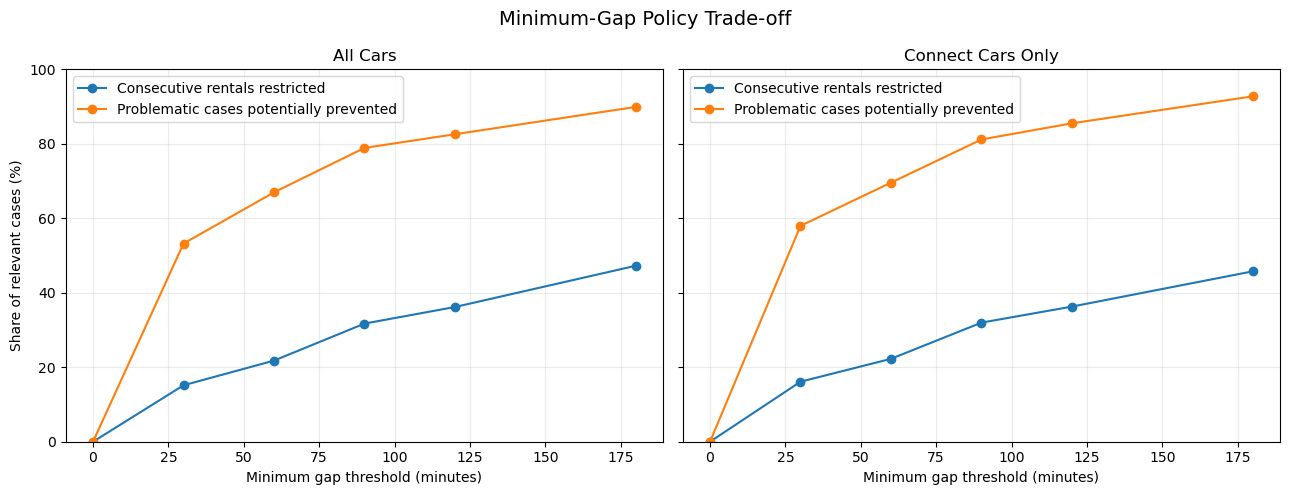

In [40]:
# Visualize the threshold trade-off
# ---------------------------------------------------------------------------

all_results = threshold_results.loc[
    threshold_results["scope"] == "all"
].copy()

connect_results = threshold_results.loc[
    threshold_results["scope"] == "connect"
].copy()

fig, axes = plt.subplots(
    ncols=2,
    figsize=(13, 5),
    sharey=True
)

# All cars
axes[0].plot(
    all_results["threshold_minutes"],
    all_results["rentals_affected_pct"],
    marker="o",
    label="Consecutive rentals restricted"
)

axes[0].plot(
    all_results["threshold_minutes"],
    all_results["problems_prevented_pct"],
    marker="o",
    label="Problematic cases potentially prevented"
)

axes[0].set_title("All Cars")
axes[0].set_xlabel("Minimum gap threshold (minutes)")
axes[0].set_ylabel("Share of relevant cases (%)")
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.25)
axes[0].legend()

# Connect cars only
axes[1].plot(
    connect_results["threshold_minutes"],
    connect_results["rentals_affected_pct"],
    marker="o",
    label="Consecutive rentals restricted"
)

axes[1].plot(
    connect_results["threshold_minutes"],
    connect_results["problems_prevented_pct"],
    marker="o",
    label="Problematic cases potentially prevented"
)

axes[1].set_title("Connect Cars Only")
axes[1].set_xlabel("Minimum gap threshold (minutes)")
axes[1].set_ylim(0, 100)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.suptitle(
    "Minimum-Gap Policy Trade-off",
    fontsize=14
)

fig.tight_layout()

plt.show()

In [42]:
# Save threshold trade-off figure
# ---------------------------------------------------------------------------

figure_path = FIGURES_PATH / "minimum_gap_policy_tradeoff.png"

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

print(f"Figure saved to: {figure_path}")

Figure saved to: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\5_Getaround_Analysis_Deployment\outputs\figures\minimum_gap_policy_tradeoff.png


## 5. Revenue Impact Analysis

The Product Manager also wants to understand what share of owner revenue could potentially be affected by the minimum-gap feature.

The delay dataset does not contain rental prices or revenue. A separate pricing dataset is available and includes vehicle characteristics, Getaround Connect availability, and rental price per day.

Before estimating monetary exposure, the pricing dataset must therefore be inspected to determine whether its observations can be linked directly to the rental-delay dataset. Any revenue estimate should distinguish between directly measurable historical exposure and a proxy derived from the separate pricing sample.


In [43]:
# Load and inspect the pricing dataset
# ---------------------------------------------------------------------------

PRICING_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "get_around_pricing_project.csv"
)

pricing_df = pd.read_csv(PRICING_DATA_PATH)

print(
    f"Pricing dataset: "
    f"{pricing_df.shape[0]:,} rows × {pricing_df.shape[1]} columns"
)

print("\nColumns:")
for i, column in enumerate(pricing_df.columns, start=1):
    print(f"{i:>2}. {column}")

Pricing dataset: 4,843 rows × 15 columns

Columns:
 1. Unnamed: 0
 2. model_key
 3. mileage
 4. engine_power
 5. fuel
 6. paint_color
 7. car_type
 8. private_parking_available
 9. has_gps
10. has_air_conditioning
11. automatic_car
12. has_getaround_connect
13. has_speed_regulator
14. winter_tires
15. rental_price_per_day


In [44]:
# Inspect pricing and Connect information
# ---------------------------------------------------------------------------

display(pricing_df.head())

print("\nMissing values:")
print(
    pricing_df[
        ["rental_price_per_day", "has_getaround_connect"]
    ].isna().sum()
)

print("\nGetaround Connect distribution:")
display(
    pricing_df["has_getaround_connect"]
    .value_counts(dropna=False)
    .rename("cars")
    .to_frame()
)

print("\nRental price summary:")
display(
    pricing_df["rental_price_per_day"]
    .describe()
    .to_frame("rental_price_per_day")
)

,Unnamed: 0,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183



Missing values:
rental_price_per_day     0
has_getaround_connect    0
dtype: int64

Getaround Connect distribution:


,cars
has_getaround_connect,
False,2613
True,2230



Rental price summary:


,rental_price_per_day
count,"4,843.00"
mean,121.21
std,33.57
min,10.00
25%,104.00
50%,119.00
75%,136.00
max,422.00


In [45]:
# Compare daily rental prices by Connect availability
# ---------------------------------------------------------------------------

price_by_connect = (
    pricing_df
    .groupby("has_getaround_connect")["rental_price_per_day"]
    .agg(
        cars="count",
        mean_price="mean",
        median_price="median",
        min_price="min",
        max_price="max"
    )
)

display(price_by_connect.round(2))

,cars,mean_price,median_price,min_price,max_price
has_getaround_connect,,,,,
False,2613,111.34,110.00,10,422
True,2230,132.79,130.00,20,378


## 5. Revenue Impact Analysis

The delay dataset does not contain rental prices or owner revenue, while the separate pricing dataset does not contain a `car_id` or `rental_id` that would allow individual rentals to be linked across the two datasets. Exact historical owner revenue exposure therefore cannot be calculated from the available data.

As an operational proxy, the analysis reports the **share of consecutive rentals that would be restricted by each minimum-gap policy**. This measures the proportion of observed close-booking situations whose historical timing would no longer be permitted. It should not be interpreted as the same proportion of rentals being lost or the same proportion of owner revenue disappearing, since affected bookings could be rescheduled or replaced.

The pricing sample nevertheless provides useful context. Connect-equipped cars have a higher average daily rental price (€132.79) than non-Connect cars (€111.34), with median prices of €130 and €110 respectively. This difference indicates that rental counts and revenue exposure are not necessarily proportional, reinforcing the need to treat the restricted-rental share as an operational exposure metric rather than a direct revenue estimate.

A precise revenue-impact analysis would require a common vehicle or rental identifier linking observed rental schedules to their corresponding rental prices.


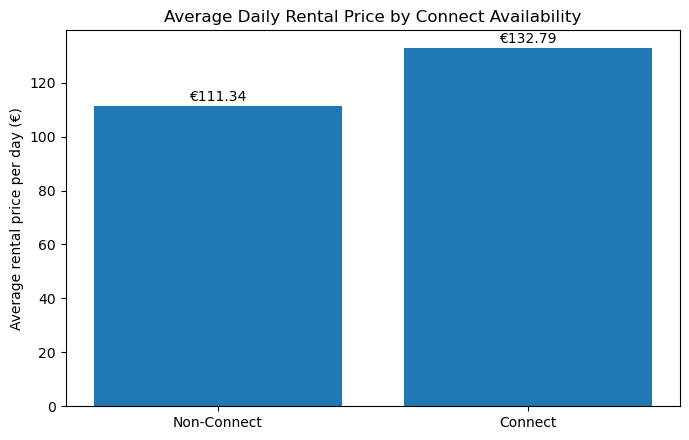

In [46]:
# Compare rental prices by Getaround Connect availability
# ---------------------------------------------------------------------------

price_plot_data = (
    pricing_df
    .groupby("has_getaround_connect")["rental_price_per_day"]
    .mean()
    .rename(index={False: "Non-Connect", True: "Connect"})
)

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    price_plot_data.index,
    price_plot_data.values
)

ax.set_title("Average Daily Rental Price by Connect Availability")
ax.set_xlabel("")
ax.set_ylabel("Average rental price per day (€)")

for bar, value in zip(bars, price_plot_data.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"€{value:.2f}",
        ha="center"
    )

fig.tight_layout()
plt.show()

In [47]:
figure_path = FIGURES_PATH / "average_price_by_connect.png"

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

print(f"Figure saved to: {figure_path}")

Figure saved to: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\5_Getaround_Analysis_Deployment\outputs\figures\average_price_by_connect.png


## 6. Impact on the Next Driver

A late checkout does not necessarily disrupt the following rental. If sufficient time exists between two rentals, the previous driver may return the car late without affecting the next driver's planned start.

To measure the actual impact on the next driver, this analysis focuses on **problematic consecutive rentals**, defined as cases where the previous rental's checkout delay exceeds the scheduled gap before the next rental:

$$
\text{Previous Checkout Delay} > \text{Scheduled Gap}
$$

For these cases, the **interference duration** measures how far the late return extends beyond the next rental's planned start:

$$
\text{Interference Minutes}
=
\text{Previous Checkout Delay}
-
\text{Scheduled Gap}
$$

For example, if a previous driver returns the car 90 minutes late and the scheduled gap is 60 minutes, the next rental is exposed to 30 minutes of interference.

The analysis examines both the distribution and severity of this interference. Problematic cases are grouped into practical duration bands (≤15, 16–30, 31–60, 61–120, and >120 minutes) to distinguish relatively short disruptions from more substantial impacts on the next driver.

Only consecutive rental pairs with an observed checkout delay for the previous rental can be evaluated. Therefore, the results describe the **1,729 analyzable consecutive pairs**, including the **218 cases previously identified as problematic**.


In [48]:
# Quantify the severity of next-driver interference
# ---------------------------------------------------------------------------

problematic = consecutive.loc[
    consecutive["problematic_case"]
].copy()

interference_summary = problematic["interference_minutes"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

print(f"Problematic consecutive cases: {len(problematic):,}")

display(
    interference_summary
    .to_frame("interference_minutes")
    .round(2)
)

Problematic consecutive cases: 218


,interference_minutes
count,218.00
mean,177.57
std,925.10
min,1.00
25%,11.00
50%,26.50
75%,80.25
90%,214.30
95%,504.05
max,"12,548.00"


In [49]:
# Categorize interference severity
# ---------------------------------------------------------------------------

problematic["interference_severity"] = pd.cut(
    problematic["interference_minutes"],
    bins=[0, 15, 30, 60, 120, np.inf],
    labels=[
        "≤ 15 min",
        "16–30 min",
        "31–60 min",
        "61–120 min",
        "> 120 min"
    ],
    include_lowest=True
)

severity_summary = (
    problematic["interference_severity"]
    .value_counts(sort=False)
    .rename("cases")
    .to_frame()
)

severity_summary["share_pct"] = (
    severity_summary["cases"]
    / severity_summary["cases"].sum()
    * 100
)

display(severity_summary.round(2))

,cases,share_pct
interference_severity,,
≤ 15 min,75,34.40
16–30 min,40,18.35
31–60 min,37,16.97
61–120 min,25,11.47
> 120 min,41,18.81


### Next-Driver Impact Findings

Among the 218 problematic consecutive rentals, the median interference with the next rental is **26.5 minutes**. The distribution is strongly right-skewed: the mean reaches 177.6 minutes because of a small number of extreme cases, so the median and percentiles provide a more representative view of typical impact.

Just over half of problematic cases (**52.8%**) result in no more than 30 minutes of interference with the next rental. However, **18.8%** exceed two hours, showing that while many disruptions are relatively short, a meaningful minority can create substantial inconvenience for the next driver.

This reinforces the distinction between a **late checkout** and an actual **next-rental problem**: the relevant product risk depends both on whether the previous driver is late and on whether that delay exceeds the scheduled gap between rentals.


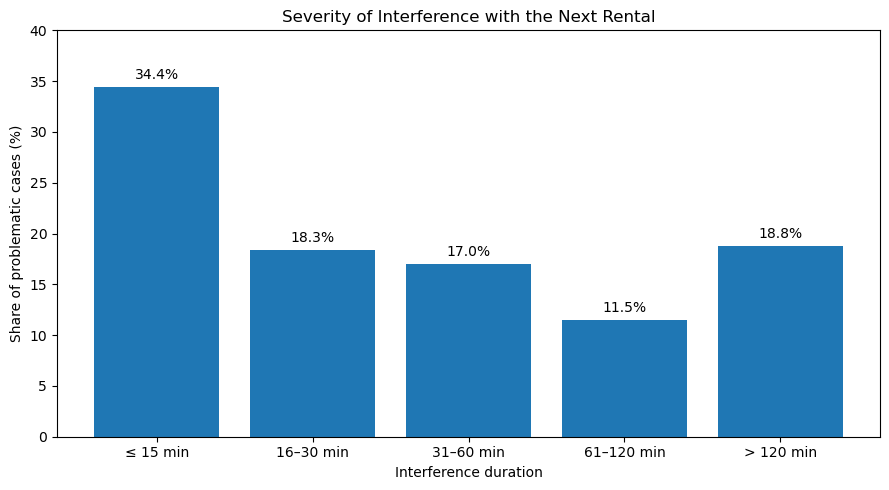

In [50]:
# Visualize next-driver interference severity
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    severity_summary.index.astype(str),
    severity_summary["share_pct"]
)

ax.set_title("Severity of Interference with the Next Rental")
ax.set_xlabel("Interference duration")
ax.set_ylabel("Share of problematic cases (%)")
ax.set_ylim(0, 40)

for i, value in enumerate(severity_summary["share_pct"]):
    ax.text(
        i,
        value + 0.8,
        f"{value:.1f}%",
        ha="center"
    )

fig.tight_layout()
plt.show()

The figure shows how the **218 problematic consecutive rentals** are distributed by interference duration. It highlights whether next-driver disruptions are primarily short delays or more severe incidents, complementing the median and percentile statistics above.


In [51]:
figure_path = FIGURES_PATH / "next_driver_interference_severity.png"

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

print(f"Figure saved to: {figure_path}")

Figure saved to: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\5_Getaround_Analysis_Deployment\outputs\figures\next_driver_interference_severity.png


## 7. Business Decision Support

The minimum-gap feature involves a trade-off between **reducing interference for the next driver** and **restricting the scheduling flexibility of car owners**.

The threshold simulation shows how this trade-off changes as the minimum permitted gap increases. Lower thresholds restrict fewer consecutive rentals but leave more historical problematic cases uncovered, while higher thresholds provide greater protection at the cost of restricting more booking configurations.

The scope decision introduces a second dimension. The policy can be applied to **all cars** or limited to **Connect-equipped cars**. The following comparison summarizes the main threshold scenarios to support the Product Manager's decision without assuming that restricted rentals necessarily translate into lost bookings or lost revenue.


In [52]:
# Create a concise policy decision table
# ---------------------------------------------------------------------------

decision_table = threshold_results[
    [
        "threshold_minutes",
        "scope",
        "rentals_affected",
        "rentals_affected_pct",
        "problems_prevented",
        "problems_prevented_pct"
    ]
].copy()

decision_table = decision_table.rename(
    columns={
        "threshold_minutes": "Minimum gap (min)",
        "scope": "Scope",
        "rentals_affected": "Restricted rentals",
        "rentals_affected_pct": "Restricted rentals (%)",
        "problems_prevented": "Problems potentially prevented",
        "problems_prevented_pct": "Problems potentially prevented (%)"
    }
)

decision_table["Scope"] = decision_table["Scope"].replace(
    {
        "all": "All cars",
        "connect": "Connect only"
    }
)

display(decision_table.round(2))


,Minimum gap (min),Scope,Restricted rentals,Restricted rentals (%),Problems potentially prevented,Problems potentially prevented (%)
0,0,All cars,0,0.00,0,0.00
1,0,Connect only,0,0.00,0,0.00
2,30,All cars,279,15.15,116,53.21
3,30,Connect only,131,16.11,40,57.97
4,60,All cars,401,21.78,146,66.97
5,60,Connect only,181,22.26,48,69.57
6,90,All cars,584,31.72,172,78.90
7,90,Connect only,260,31.98,56,81.16
8,120,All cars,666,36.18,180,82.57
9,120,Connect only,295,36.29,59,85.51


### Policy Trade-off Interpretation

The largest initial improvement occurs with relatively short minimum gaps. A **30-minute threshold** would restrict about 15–16% of observed consecutive rentals while potentially preventing 53–58% of historical problematic cases. At **60 minutes**, approximately 22% of consecutive rentals would be restricted while 67–70% of problematic cases would be covered.

Increasing the threshold to **90 minutes** raises potential prevention to approximately 79–81%, but the share of restricted consecutive rentals also rises to about 32%. Beyond this point, the additional protection becomes smaller relative to the additional scheduling restrictions: a 180-minute threshold would potentially cover around 90–93% of problematic cases but restrict approximately 46–47% of observed consecutive rentals.

The results therefore show **diminishing returns as the minimum gap increases**. The final threshold choice depends on Getaround's tolerance for next-driver disruption relative to the value of preserving owner scheduling flexibility.

The scope comparison is relatively similar in percentage terms across the tested thresholds. Restricting the feature to Connect cars would reduce the absolute number of rentals subject to the policy, while applying it to all cars would address problematic cases across the full observed population.


## 8. Limitations

Several limitations should be considered when interpreting the results:

* **Incomplete checkout-delay information:** 1,700 ended rentals have no observed checkout delay. Consecutive-rental interference can therefore only be evaluated when the previous rental's checkout delay is available; no missing delays were imputed.
* **12-hour observation window:** the dataset only identifies a previous ended rental when the planned gap is below 12 hours. Threshold results therefore describe consecutive-rental situations within this window rather than all rentals.
* **Historical simulation, not causal evidence:** problematic cases classified as potentially prevented are cases whose historical booking configuration would have violated the proposed threshold. The analysis cannot guarantee that implementing the feature would eliminate every such problem.
* **Booking response is unknown:** a restricted rental does not necessarily represent a lost rental. Drivers or owners may reschedule, choose another vehicle, or otherwise adapt.
* **Revenue cannot be linked directly:** the pricing dataset contains rental prices but no common `car_id` or `rental_id` linking it to the delay dataset. The share of restricted rentals is therefore an operational exposure measure, not an estimate of revenue lost.


## 9. Business Recommendation

The analysis supports using a **60-minute minimum gap as a practical starting point for product testing**. Historically, this threshold would have restricted **21.78% of consecutive rentals** under an all-cars policy while potentially preventing **66.97% of observed problematic cases**. For Connect cars only, the corresponding figures are **22.26% restricted** and **69.57% potentially prevented**.

A 30-minute threshold imposes fewer scheduling restrictions but leaves roughly 42–47% of historical problematic cases uncovered. Increasing the threshold to 90 minutes provides additional protection, but the share of restricted consecutive rentals rises to approximately 32%. The incremental protection becomes progressively smaller at higher thresholds.

For deployment scope, **Connect-only provides a narrower rollout option**, limiting the feature to a smaller absolute population while retaining a similar threshold trade-off within that group. An all-cars rollout addresses a larger number of problematic situations but also subjects more rentals to the scheduling constraint.

A reasonable product approach would therefore be to **test a 60-minute threshold on Connect cars first**, monitor actual booking conversion, rescheduling, cancellations, owner revenue, and next-driver incidents, and use those observed outcomes before considering broader deployment or a higher threshold.

This recommendation should be treated as a product-testing strategy rather than a claim that 60 minutes is mathematically optimal, since the available data does not measure the behavioral or revenue consequences of introducing the restriction.


## 10. Conclusion

Late checkout is common, but lateness alone does not determine whether the next driver is affected. Among **1,729 analyzable consecutive rental pairs**, 50.49% of previous rentals were returned late, while only **12.61%** resulted in direct interference with the following rental. Among late previous rentals, approximately **25%** actually exceeded the available scheduled gap.

When interference occurs, its median duration is **26.5 minutes**, although a minority of cases are substantially more severe. This confirms that the product decision should focus on protecting genuinely exposed consecutive rentals rather than attempting to eliminate late checkout itself.

Threshold simulation reveals a clear trade-off between customer protection and scheduling flexibility. A **60-minute minimum gap** provides a balanced candidate for testing, potentially covering about two-thirds of historical problematic cases while restricting roughly one-fifth of observed consecutive rental configurations.

The analysis therefore supports a **60-minute Connect-only initial rollout as a testable product strategy**, followed by measurement of actual booking, revenue, and customer-experience outcomes before expanding the feature.

Because rental prices cannot be linked directly to the delay observations, the analysis does not estimate actual revenue loss. Future evaluation should combine rental-level scheduling, pricing, booking outcomes, and post-launch behavior to quantify the feature's economic impact more precisely.
